In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Text(0, 0.5, 'Resposta [eu]')

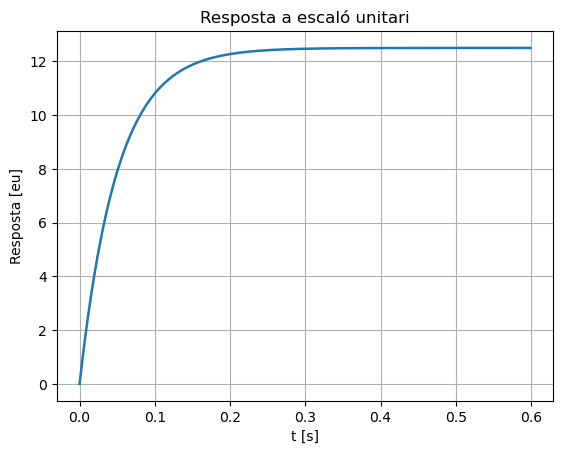

In [2]:
tau = 0.05
K = 300 / 24

# Gm(s) = K / (tau s + 1)
numG = [K]
denG = [tau, 1]

G_m = signal.lti(numG, denG)

# temps i entrada escaló
t = np.arange(0, 0.6, 0.001)
u = np.ones_like(t)

# resposta llaç obert
t_ol, y_ol, _ = signal.lsim(G_m, U=u, T=t)

plt.figure()
plt.plot(t_ol, y_ol, linewidth=1.8)
plt.grid()
plt.title('Resposta a escaló unitari')
plt.xlabel('t [s]')
plt.ylabel('Resposta [eu]')

Text(0, 0.5, 'dB')

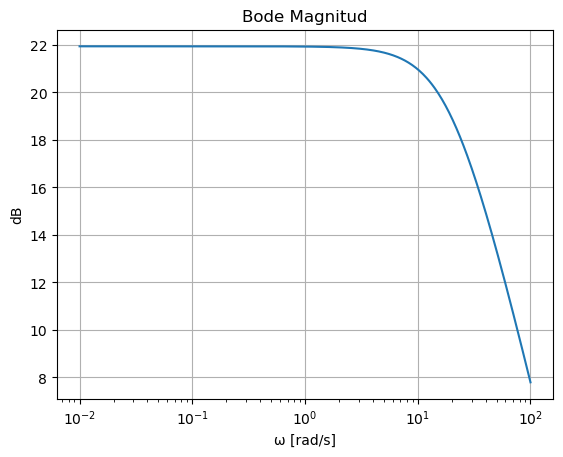

In [3]:
w = np.logspace(-2, 2, 500)
w, H = signal.freqresp((numG, denG), w)

plt.figure()
plt.semilogx(w, 20 * np.log10(np.abs(H)))
plt.grid()
plt.title("Bode Magnitud")
plt.xlabel("ω [rad/s]")
plt.ylabel("dB")

Text(0, 0.5, 'Imag')

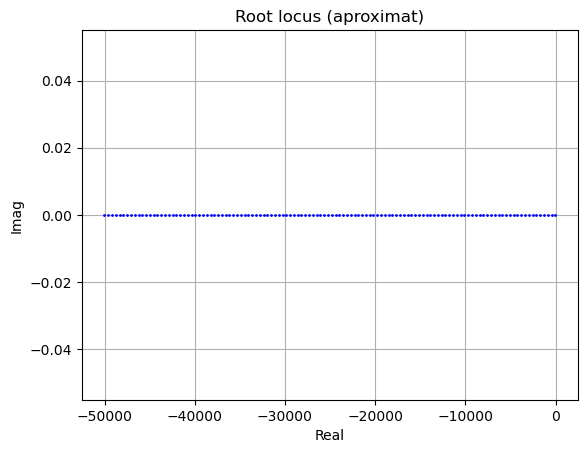

In [4]:
K_values = np.linspace(0, 200, 120)
poles_list = []

for Kk in K_values:
    numK = np.polymul([Kk], numG)
    den_cl = np.polyadd(denG, numK)
    poles_list.append(np.roots(den_cl))

plt.figure()
for p in poles_list:
    plt.plot(np.real(p), np.imag(p), 'b.', markersize=2)

plt.grid()
plt.title("Root locus (aproximat)")
plt.xlabel("Real")
plt.ylabel("Imag")

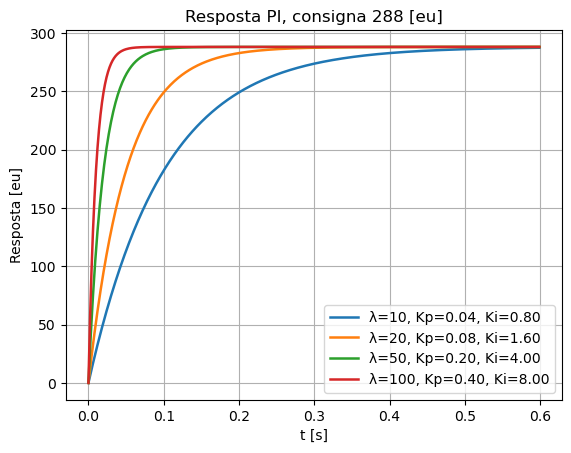

In [5]:
lambda_ = [10, 20, 50, 100]

u = 288
u_t = u * np.ones_like(t)

responses = []
labels = []
Kp_list = []

for lam in lambda_:

    Kp = tau / K * lam
    Ti = tau
    Ki = Kp / Ti

    # PI: (Kp*s + Ki)/s
    numC = [Kp, Ki]
    denC = [1, 0]

    # planta
    numG = [K]
    denG = [tau, 1]

    # open loop
    num_ol = np.polymul(numC, numG)
    den_ol = np.polymul(denC, denG)

    # closed loop: T = N / (D + N)
    num_cl = num_ol
    den_cl = np.polyadd(den_ol, num_ol)

    sys_cl = signal.lti(num_cl, den_cl)

    t_out, y, _ = signal.lsim(sys_cl, U=u_t, T=t)

    responses.append(y)
    labels.append(f"λ={lam}, Kp={Kp:.2f}, Ki={Ki:.2f}")
    Kp_list.append(Kp)


plt.figure()

for y, lab in zip(responses, labels):
    plt.plot(t, y, linewidth=1.8, label=lab)

plt.grid()
plt.title(f'Resposta PI, consigna {u} [eu]')
plt.xlabel('t [s]')
plt.ylabel('Resposta [eu]')
plt.legend()
plt.show()

In [6]:
Ti = tau
e_v = 1 / ((1 / Ti) * K)

print(f"Error estacionari (velocitat): {e_v:.4f} eu")

Error estacionari (velocitat): 0.0040 eu
